In [4]:
from pathlib import Path
import json
import numpy as np
from PIL import Image
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
PROJECT_ROOT = Path("..")
MODEL_DIR = PROJECT_ROOT / "models"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

model = tf.keras.models.load_model(MODEL_DIR / "mobilenetv2_acne_classifier.keras")

with open(MODEL_DIR / "class_names.json", "r") as f:
    class_names = json.load(f)

class_names

['acne_scars', 'comedonal_closed', 'comedonal_open', 'inflammatory_acne']

In [3]:
def predict_image(image_path):
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize((224, 224))

    img_array = np.array(img_resized)
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)[0]

    predicted_index = np.argmax(predictions)
    predicted_class = class_names[predicted_index]
    confidence = predictions[predicted_index]

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {predicted_class} ({confidence:.2%})")
    plt.show()

    return predicted_class, confidence, predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


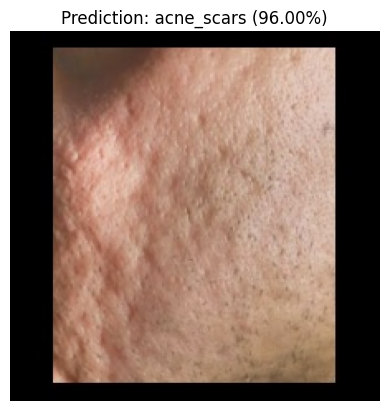

('acne_scars',
 np.float32(0.95996577),
 array([0.95996577, 0.02131024, 0.01766726, 0.00105673], dtype=float32))

In [8]:
test_df = pd.read_csv(PROCESSED_DIR / "test.csv")

sample_path = test_df["processed_path"].iloc[1]
predict_image(sample_path)